In [ ]:
import numpy as np

class CameraPose:

    def __init__(self, meta, mat):
        self.metadata = meta
        self.pose = mat

    def __str__(self):
        return 'Metadata : ' + ' '.join(map(str, self.metadata)) + '\n' + \
            "Pose : " + "\n" + np.array_str(self.pose)


def read_trajectory(filename):
    traj = []
    with open(filename, 'r') as f:
        metastr = f.readline()
        while metastr:
            metadata = list(map(int, metastr.split()))
            print(metadata)
            mat = np.zeros(shape=(4, 4))
            for i in range(4):
                matstr = f.readline()
                mat[i, :] = np.fromstring(matstr, dtype=float, sep=' \t')
            traj.append(CameraPose(metadata, mat))
            metastr = f.readline()
    return traj

In [ ]:
import open3d as o3d
import numpy as np
'''
# odometry.log
0   0   1
1   0   0   2
0   1   0   2
0   0   1 -0.3
0   0   0   1
1   1   2
0.999988  3.08668e-005  0.0049181  1.99962
-8.84184e-005  0.999932  0.0117022  1.97704
-0.0049174  -0.0117024  0.999919  -0.300486
0  0  0  1
'''

redwood_rgbd = o3d.data.SampleRedwoodRGBDImages()
camera_poses = read_trajectory(redwood_rgbd.odometry_log_path)

In [ ]:
volume = o3d.pipelines.integration.ScalableTSDFVolume(
    voxel_length=4.0 / 512.0,
    sdf_trunc=0.04,
    color_type=o3d.pipelines.integration.TSDFVolumeColorType.RGB8)

for i in range(len(camera_poses)):
    print("Integrate {:d}-th image into the volume.".format(i))
    color = o3d.io.read_image(redwood_rgbd.color_paths[i])
    depth = o3d.io.read_image(redwood_rgbd.depth_paths[i])
    rgbd = o3d.geometry.RGBDImage.create_from_color_and_depth(
        color, depth, depth_trunc=4.0, convert_rgb_to_intensity=False)
    volume.integrate(
        rgbd,
        o3d.camera.PinholeCameraIntrinsic(
            o3d.camera.PinholeCameraIntrinsicParameters.PrimeSenseDefault),
        np.linalg.inv(camera_poses[i].pose))

| 參數名稱     | 型別 | 是否必填 | 意義 |
|--------------|------|----------|------|
| voxel_length | float | ✔ | 每個 TSDF voxel 的邊長（世界座標單位，通常是公尺）。值越小解析度越高，但記憶體與計算成本越大。 |
| sdf_trunc    | float | ✔ | TSDF 的截斷距離（truncation distance）。只在距離表面 ±sdf_trunc 內更新 SDF，超過就視為飽和。控制表面厚度與平滑程度。 |
| color_type   | o3d.pipelines.integration.TSDFVolumeColorType | ✔ | 要不要儲存顏色，以及用什麼格式儲存顏色（沒有顏色 / 8bit RGB / float RGB）。決定最後 mesh/pcd 是否有 color。 |

| 值 | 意義 |
|----|------|
| TSDFVolumeColorType.NoColor | 不儲存顏色，只做幾何表面（灰白 mesh） |
| TSDFVolumeColorType.RGB8    | 使用 uint8 RGB 顏色（0–255），一般最常用 |
| TSDFVolumeColorType.Gray32  | 使用 float 灰階（少用） |

| enum 名稱 | 意義 |
|-----------|------|
| PinholeCameraIntrinsicParameters.PrimeSenseDefault | 640×480 的預設深度相機參數（類似舊款 Kinect/PrimeSense） |
| PinholeCameraIntrinsicParameters.Kinect2DepthCameraDefault | Kinect v2 depth 相機內參（特定解析度） |
| PinholeCameraIntrinsicParameters.Kinect2ColorCameraDefault | Kinect v2 color 相機內參 |

In [ ]:
print("Extract a triangle mesh from the volume and visualize it.")
mesh = volume.extract_triangle_mesh()
mesh.compute_vertex_normals()
o3d.visualization.draw_geometries([mesh],
                                  front=[0.5297, -0.1873, -0.8272],
                                  lookat=[2.0712, 2.0312, 1.7251],
                                  up=[-0.0558, -0.9809, 0.1864],
                                  zoom=0.47)

In [ ]:
redwood_rgbd = o3d.data.SampleRedwoodRGBDImages()

pinhole_camera_intrinsic = o3d.io.read_pinhole_camera_intrinsic(
    redwood_rgbd.camera_intrinsic_path)
print(redwood_rgbd.camera_intrinsic_path)
print(pinhole_camera_intrinsic.intrinsic_matrix)

In [ ]:
source_color = o3d.io.read_image(redwood_rgbd.color_paths[0])
source_depth = o3d.io.read_image(redwood_rgbd.depth_paths[0])
target_color = o3d.io.read_image(redwood_rgbd.color_paths[1])
target_depth = o3d.io.read_image(redwood_rgbd.depth_paths[1])
print(redwood_rgbd.color_paths[0], redwood_rgbd.color_paths[1])
source_rgbd_image = o3d.geometry.RGBDImage.create_from_color_and_depth(
    source_color, source_depth)
target_rgbd_image = o3d.geometry.RGBDImage.create_from_color_and_depth(
    target_color, target_depth)
target_pcd = o3d.geometry.PointCloud.create_from_rgbd_image(
    target_rgbd_image, pinhole_camera_intrinsic)

In [ ]:
option = o3d.pipelines.odometry.OdometryOption()
odo_init = np.identity(4)
print(option)

[success_color_term, trans_color_term,
 info] = o3d.pipelines.odometry.compute_rgbd_odometry(
     source_rgbd_image, target_rgbd_image, pinhole_camera_intrinsic, odo_init,
     o3d.pipelines.odometry.RGBDOdometryJacobianFromColorTerm(), option)
[success_hybrid_term, trans_hybrid_term,
 info] = o3d.pipelines.odometry.compute_rgbd_odometry(
     source_rgbd_image, target_rgbd_image, pinhole_camera_intrinsic, odo_init,
     o3d.pipelines.odometry.RGBDOdometryJacobianFromHybridTerm(), option)

In [ ]:
if success_color_term:
    print("Using RGB-D Odometry")
    print(trans_color_term)
    source_pcd_color_term = o3d.geometry.PointCloud.create_from_rgbd_image(
        source_rgbd_image, pinhole_camera_intrinsic)
    source_pcd_color_term.transform(trans_color_term)
    o3d.visualization.draw_geometries([target_pcd, source_pcd_color_term],
                                      zoom=0.48,
                                      front=[0.0999, -0.1787, -0.9788],
                                      lookat=[0.0345, -0.0937, 1.8033],
                                      up=[-0.0067, -0.9838, 0.1790])
if success_hybrid_term:
    print("Using Hybrid RGB-D Odometry")
    print(trans_hybrid_term)
    source_pcd_hybrid_term = o3d.geometry.PointCloud.create_from_rgbd_image(
        source_rgbd_image, pinhole_camera_intrinsic)
    source_pcd_hybrid_term.transform(trans_hybrid_term)
    o3d.visualization.draw_geometries([target_pcd, source_pcd_hybrid_term],
                                      zoom=0.48,
                                      front=[0.0999, -0.1787, -0.9788],
                                      lookat=[0.0345, -0.0937, 1.8033],
                                      up=[-0.0067, -0.9838, 0.1790])

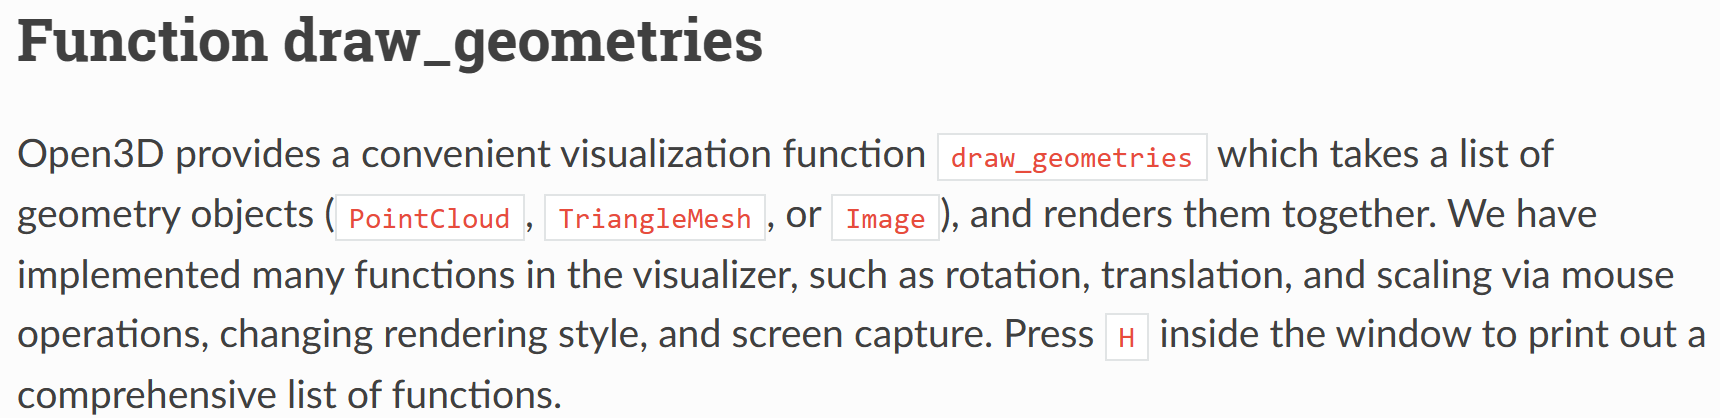

In [ ]:
print("Load a ply point cloud, print it, and render it")
sample_ply_data = o3d.data.PLYPointCloud()
pcd = o3d.io.read_point_cloud(sample_ply_data.path)
o3d.visualization.draw_geometries([pcd],
                                  zoom=0.3412,
                                  front=[0.4257, -0.2125, -0.8795],
                                  lookat=[2.6172, 2.0475, 1.532],
                                  up=[-0.0694, -0.9768, 0.2024])

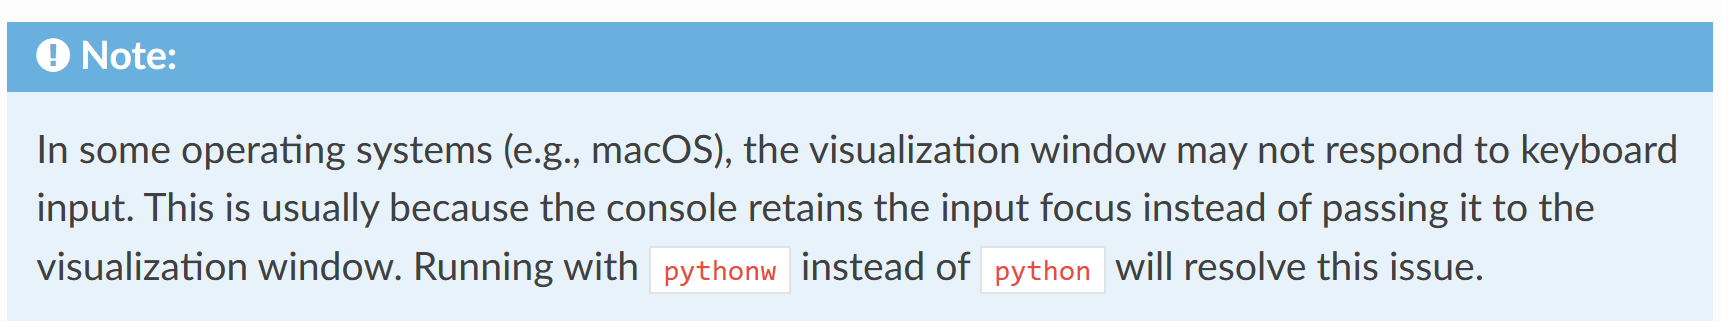

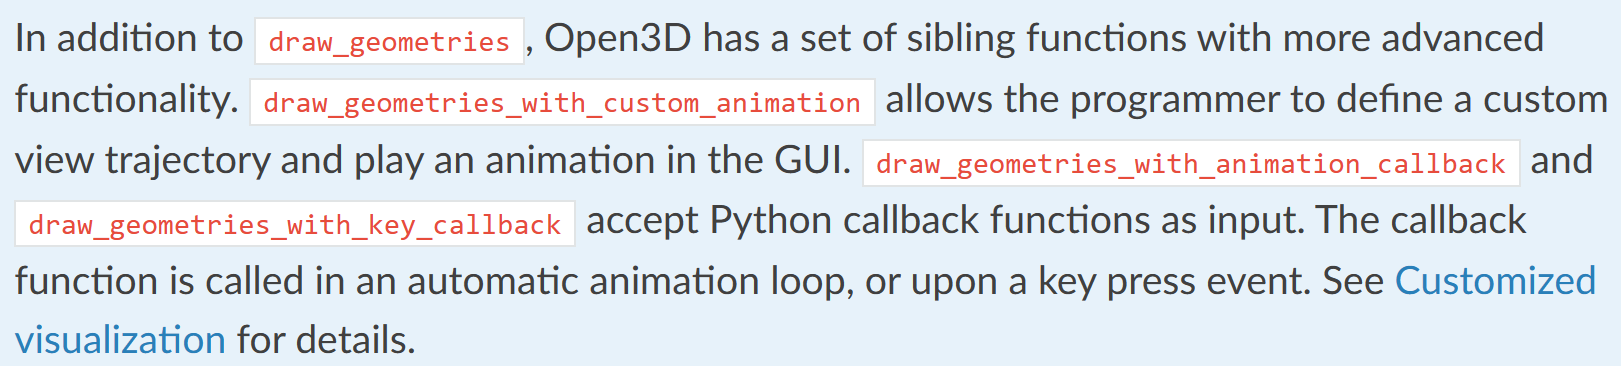

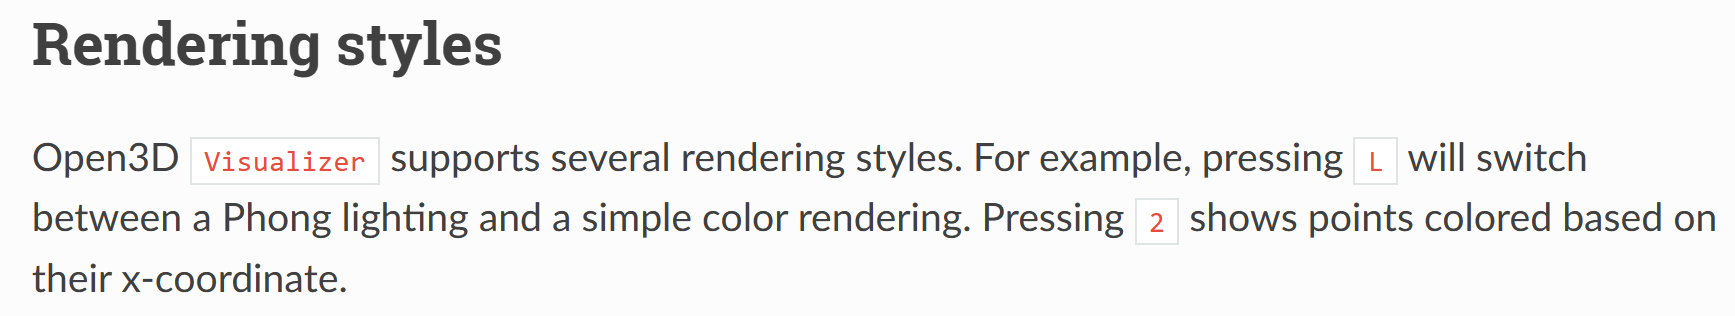
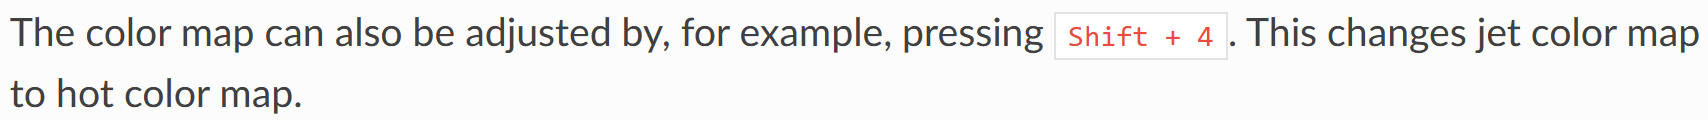

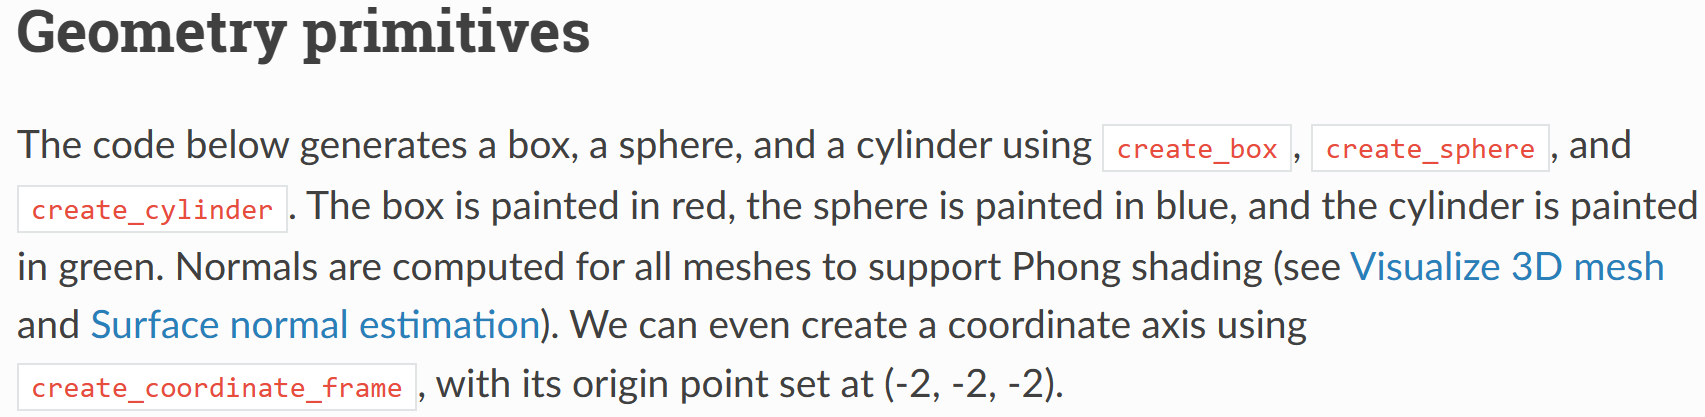

In [ ]:
print("Let's define some primitives")
mesh_box = o3d.geometry.TriangleMesh.create_box(width=1.0,
                                                height=1.0,
                                                depth=1.0)
mesh_box.compute_vertex_normals()
mesh_box.paint_uniform_color([0.9, 0.1, 0.1])
mesh_sphere = o3d.geometry.TriangleMesh.create_sphere(radius=1.0)
mesh_sphere.compute_vertex_normals()
mesh_sphere.paint_uniform_color([0.1, 0.1, 0.7])
mesh_cylinder = o3d.geometry.TriangleMesh.create_cylinder(radius=0.3,
                                                          height=4.0)
mesh_cylinder.compute_vertex_normals()
mesh_cylinder.paint_uniform_color([0.1, 0.9, 0.1])
mesh_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(
    size=0.6, origin=[0, 0, 0])

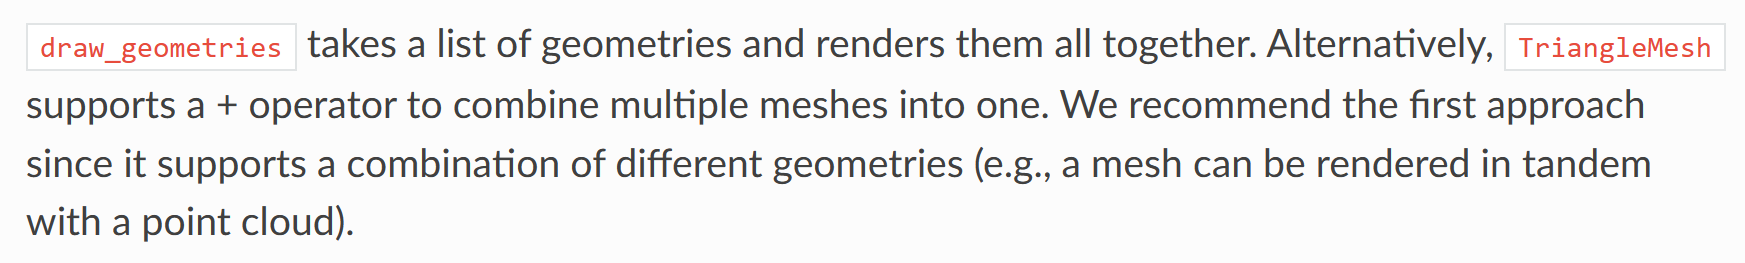

In [ ]:
print("We draw a few primitives using collection.")
o3d.visualization.draw_geometries(
    [mesh_box,mesh_frame])

print("We draw a few primitives using + operator of mesh.")
o3d.visualization.draw_geometries(
    [mesh_box + mesh_sphere + mesh_cylinder + mesh_frame])

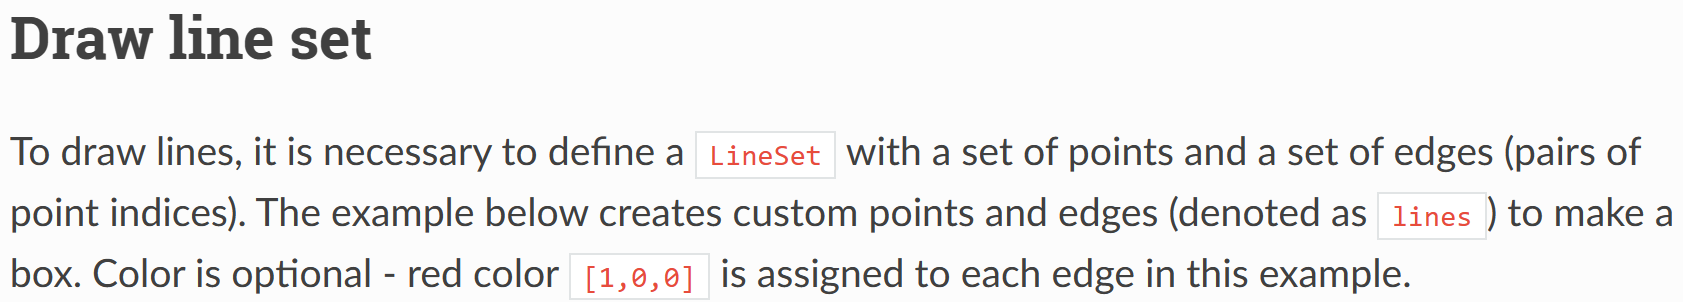

In [ ]:
print("Let's draw a box using o3d.geometry.LineSet.")
points = [
    [0, 0, 0],
    [1, 0, 0],
    [0, 1, 0],
    [1, 1, 0],
    [0, 0, 1],
    [1, 0, 1],
    [0, 1, 1],
    [1, 1, 1],
]
lines = [
    [0, 1],
    [0, 2],
    [1, 3],
    [2, 3],
    [4, 5],
    [4, 6],
    [5, 7],
    [6, 7],
    [0, 4],
    [1, 5],
    [2, 6],
    [3, 7],
]
colors = [[1, 0, 0] for i in range(len(lines))]
line_set = o3d.geometry.LineSet(
    points=o3d.utility.Vector3dVector(points),
    lines=o3d.utility.Vector2iVector(lines),
)
line_set.colors = o3d.utility.Vector3dVector(colors)
o3d.visualization.draw_geometries([line_set])

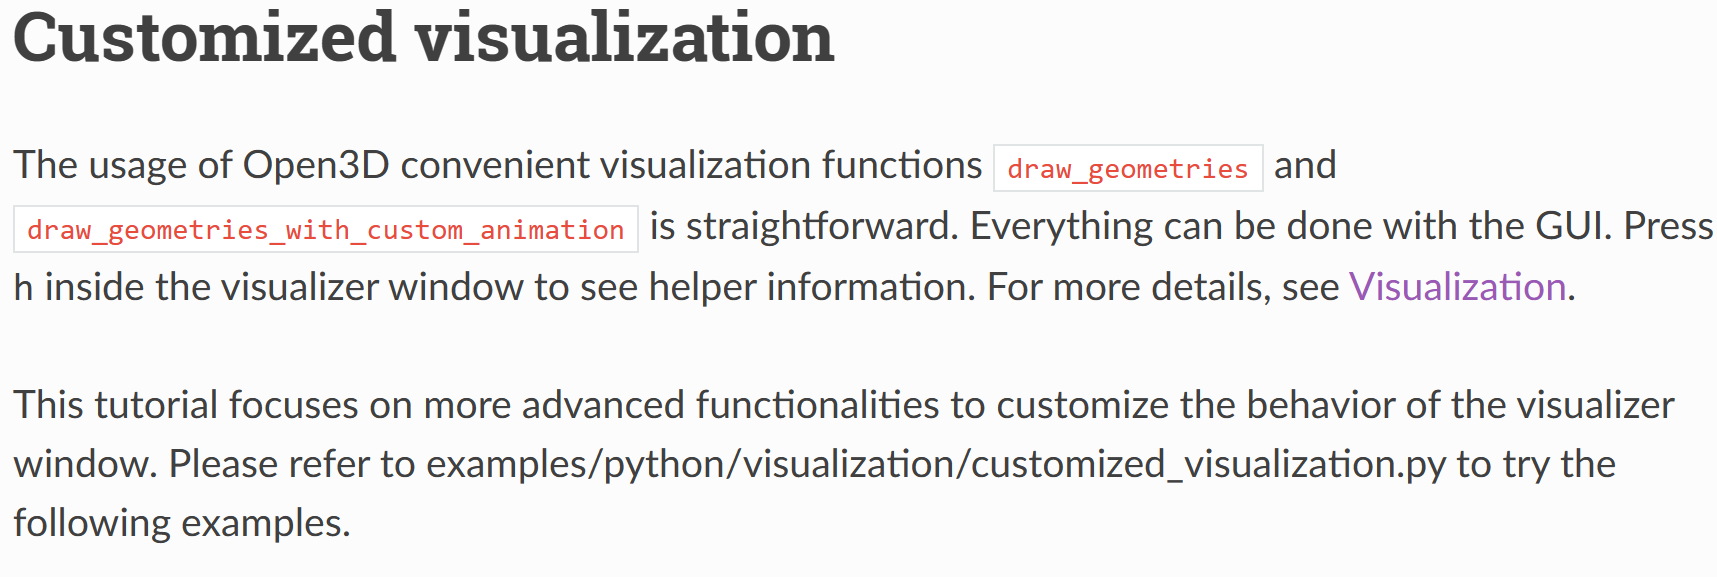

In [ ]:
def custom_draw_geometry(pcd):
    # The following code achieves the same effect as:
    # o3d.visualization.draw_geometries([pcd])
    vis = o3d.visualization.Visualizer()
    vis.create_window()
    vis.add_geometry(pcd)
    vis.run()
    vis.destroy_window()

sample_ply_data = o3d.data.PLYPointCloud()
pcd = o3d.io.read_point_cloud(sample_ply_data.path)
custom_draw_geometry(pcd)

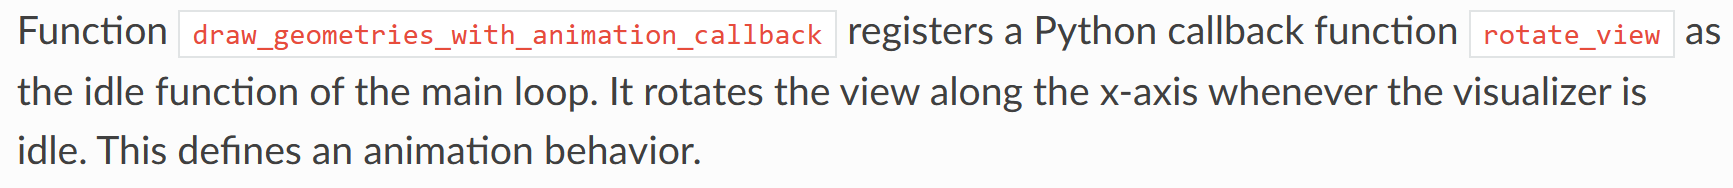

In [ ]:
def custom_draw_geometry_with_rotation(pcd):

    def rotate_view(vis):
        ctr = vis.get_view_control()
        ctr.rotate(10.0, 0.0)
        return False

    o3d.visualization.draw_geometries_with_animation_callback([pcd],
                                                              rotate_view)

sample_ply_data = o3d.data.PLYPointCloud()
pcd = o3d.io.read_point_cloud(sample_ply_data.path)
custom_draw_geometry_with_rotation(pcd)

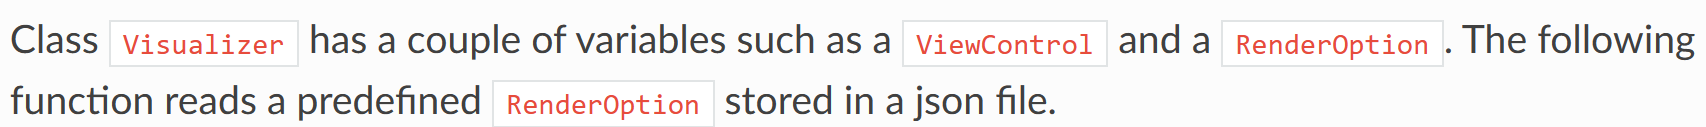

In [ ]:
import matplotlib.pyplot as plt
def custom_draw_geometry_with_key_callback(pcd, render_option_path):

    def change_background_to_black(vis):
        opt = vis.get_render_option()
        opt.background_color = np.asarray([0, 0, 0])
        return False

    def load_render_option(vis):
        vis.get_render_option().load_from_json(render_option_path)
        return False

    def capture_depth(vis):
        depth = vis.capture_depth_float_buffer()
        plt.imshow(np.asarray(depth))
        plt.show()
        return False

    def capture_image(vis):
        image = vis.capture_screen_float_buffer()
        plt.imshow(np.asarray(image))
        plt.show()
        return False

    key_to_callback = {}
    key_to_callback[ord("K")] = change_background_to_black
    key_to_callback[ord("R")] = load_render_option
    key_to_callback[ord(",")] = capture_depth
    key_to_callback[ord(".")] = capture_image
    o3d.visualization.draw_geometries_with_key_callbacks([pcd], key_to_callback)

sample_data = o3d.data.DemoCustomVisualization()
pcd_flipped = o3d.io.read_point_cloud(sample_data.point_cloud_path)
pcd_flipped.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0],
                           [0, 0, 0, 1]])
custom_draw_geometry_with_key_callback(pcd_flipped, sample_data.render_option_path)


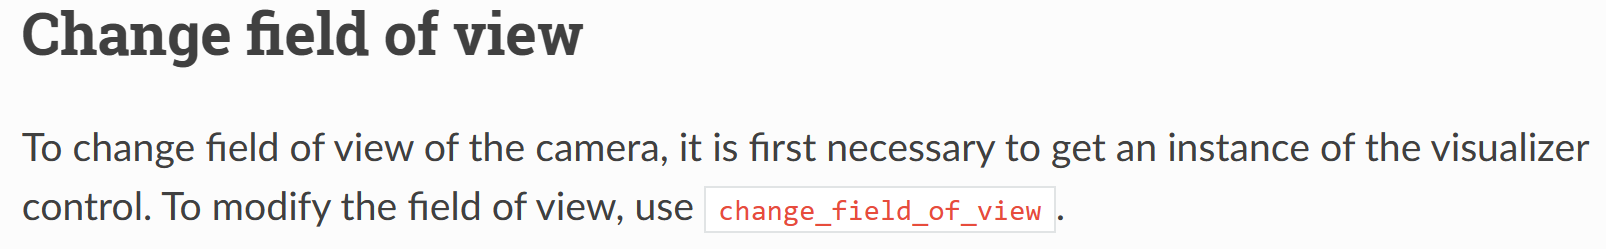

In [ ]:
def custom_draw_geometry_with_custom_fov(pcd, fov_step):
    vis = o3d.visualization.Visualizer()
    vis.create_window()
    vis.add_geometry(pcd)
    ctr = vis.get_view_control()
    print("Field of view (before changing) %.2f" % ctr.get_field_of_view())
    ctr.change_field_of_view(step=fov_step)
    print("Field of view (after changing) %.2f" % ctr.get_field_of_view())
    vis.run()
    vis.destroy_window()

custom_draw_geometry_with_custom_fov(pcd_flipped, 5)
#custom_draw_geometry_with_custom_fov(pcd_flipped, -90.0)


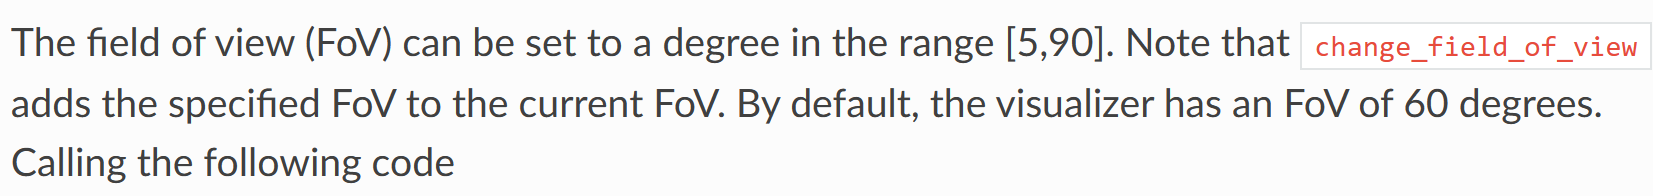

In [ ]:
import open3d as o3d
import matplotlib.pyplot as plt
import os
import numpy as np

#pyexample_path = os.path.dirname(os.path.dirname(os.path.abspath('./test')))
test_data_path = os.path.join('test_data')

def custom_draw_geometry_with_camera_trajectory(pcd, render_option_path,
                                                camera_trajectory_path):
    custom_draw_geometry_with_camera_trajectory.index = -1
    custom_draw_geometry_with_camera_trajectory.trajectory =\
        o3d.io.read_pinhole_camera_trajectory(camera_trajectory_path)
    custom_draw_geometry_with_camera_trajectory.vis = o3d.visualization.Visualizer(
    )
    image_path = os.path.join(test_data_path, 'image')
    if not os.path.exists(image_path):
        os.makedirs(image_path)
    depth_path = os.path.join(test_data_path, 'depth')
    if not os.path.exists(depth_path):
        os.makedirs(depth_path)

    def move_forward(vis):
        # This function is called within the o3d.visualization.Visualizer::run() loop
        # The run loop calls the function, then re-render
        # So the sequence in this function is to:
        # 1. Capture frame
        # 2. index++, check ending criteria
        # 3. Set camera
        # 4. (Re-render)
        ctr = vis.get_view_control()
        glb = custom_draw_geometry_with_camera_trajectory
        if glb.index >= 0:
            print("Capture image {:05d}".format(glb.index))
            depth = vis.capture_depth_float_buffer(False)
            image = vis.capture_screen_float_buffer(False)
            plt.imsave(os.path.join(depth_path, '{:05d}.png'.format(glb.index)),
                       np.asarray(depth),
                       dpi=1)
            plt.imsave(os.path.join(image_path, '{:05d}.png'.format(glb.index)),
                       np.asarray(image),
                       dpi=1)
            # vis.capture_depth_image("depth/{:05d}.png".format(glb.index), False)
            # vis.capture_screen_image("image/{:05d}.png".format(glb.index), False)
        glb.index = glb.index + 1
        if glb.index < len(glb.trajectory.parameters):
            ctr.convert_from_pinhole_camera_parameters(
                glb.trajectory.parameters[glb.index], allow_arbitrary=True)
        else:
            custom_draw_geometry_with_camera_trajectory.vis.register_animation_callback(None)
        return False

    vis = custom_draw_geometry_with_camera_trajectory.vis
    vis.create_window()
    vis.add_geometry(pcd)
    vis.get_render_option().load_from_json(render_option_path)
    vis.register_animation_callback(move_forward)
    vis.run()
    vis.destroy_window()

sample_data = o3d.data.DemoCustomVisualization()
pcd = o3d.io.read_point_cloud(sample_data.point_cloud_path)
custom_draw_geometry_with_camera_trajectory(pcd, sample_data.render_option_path, sample_data.camera_trajectory_path)



In [ ]:
import open3d as o3d
import open3d.visualization.gui as gui
#from open3d.cpu.pybind.visualization import gui
import open3d.visualization.rendering as rendering
import sys, os

def main():
    #if len(sys.argv) < 2:
    #    print ("Usage: texture-model.py [model directory]\n\t This example will load [model directory].obj and any of albedo, normal, ao, metallic and roughness textures present.")
    #    exit()
    sample = o3d.data.MetalTexture()
    
    # Derive the object path set the model, material, and shader
   #model_dir = sys.argv[1]
    model_dir = 'MonkeyModel'
    model_name = os.path.join(model_dir, "monkey.obj")
    print(model_name)
    model = o3d.io.read_triangle_mesh(model_name)
    material = o3d.visualization.rendering.MaterialRecord()
    material.shader = "defaultLit"

    # Derive the texture paths
    albedo_name = os.path.join(model_dir, "albedo.png")
    normal_name = os.path.join(model_dir, "normal.png")
    ao_name = os.path.join(model_dir, "ao.png")
    metallic_name = os.path.join(model_dir, "metallic.png")
    roughness_name = os.path.join(model_dir, "roughness.png")

    # Check if the textures are available and loads the texture. For example, if metallic exists then load metallic texture
    if os.path.exists(albedo_name):
        material.albedo_img = o3d.io.read_image(albedo_name)
    #if os.path.exists(normal_name):
       #material.normal_img = o3d.io.read_image(normal_name)
    #if os.path.exists(ao_name):
    #    material.ao_img = o3d.io.read_image(ao_name)
    #if os.path.exists(metallic_name):
    #    material.base_metallic = 1.0
    #    material.metallic_img = o3d.io.read_image(metallic_name)
    #if os.path.exists(roughness_name):
    #    material.roughness_img = o3d.io.read_image(roughness_name)

    # Draw an object named cube using the available model and texture
    o3d.visualization.draw([{"name": "monkey", "geometry": model, "material": material}])
    
if __name__ == "__main__":
 main()

| Shader 名稱 | 光照 | 支援 PBR 參數 | 適合用途 | 說明 |
|-------------|------|---------------|----------|------|
| defaultLit | ✔️ | base_color, metallic, roughness, normal_map | mesh、真實渲染 | **最推薦的預設選擇** |
| phong | ✔️ | 部分 | 傳統光照 | 比 PBR 亮但不寫實 |
| defaultUnlit | ❌ | 只顏色 | 點雲、貼圖、debug | 不受光線影響 |
| unlit | ❌ | 同 defaultUnlit | 點雲、影像 | 舊名稱 |
| normals | 偽光照 | 無 | debug 法向量 | 用顏色顯示 normal |
| depth | ❌ | 無 | debug 深度 | 灰階顯示深度 |
| unlitLine | ❌ | 無（可 line_width） | LineSet | 畫線段時使用 |

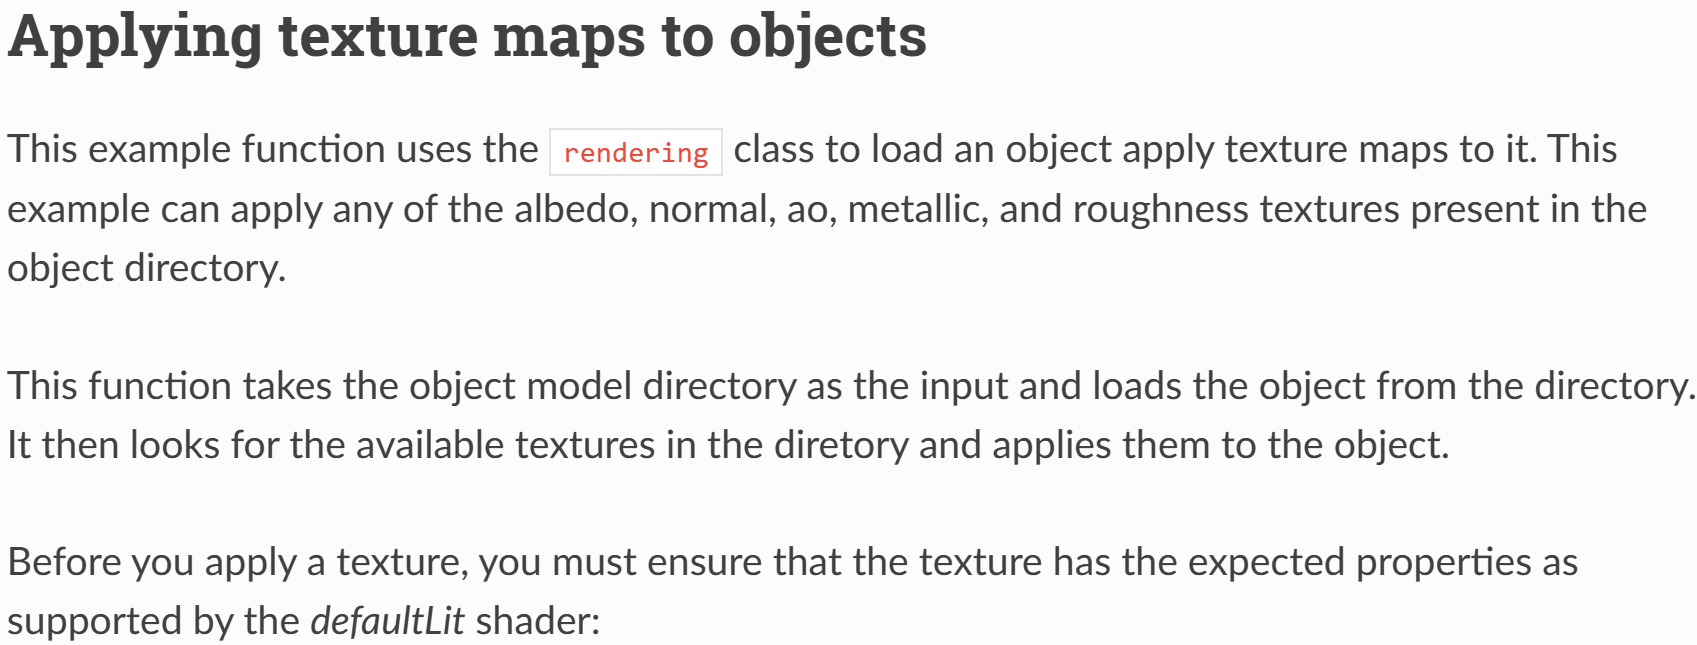

**albedo: This must be a 3 or 4 channel image, where the RGB components are the albedo. If there is a 4th channel, then it is the alpha channel for transparency. The defaultLit does not support transparency. You must use defaultLitTransparency instead of defaultLit to use transparency, that is similar to defaultLit except that it used alpha channel for transparency.

**normal: This must be a 3 channel image, where RGB components represent the normal in tangent space at each pixel.

**roughness: This can be 1, 2, 3, or 4 channel image. However, only the 1st channel (Red) is used and indicates the applicable roughness. The value ranges from 0, smooth and highly glossy, to 1, very rough and diffuse.

**metallic: This can be 1, 2,3 , or 4 channel image. However, only the 1st channel (Red) is used and indicates the applicable metallic finish. The value ranges from 0, non-metallic, to 1, metallic. Note that the values in between are generally not physically realistic.

**ao: This can be 1, 2 ,3, or 4 channel image. However, only the 1st channel (Red) is used and indicates the ambient occlusion. The value ranges from 0, indicating all pixels are fully shadowed and not exposed to indirect lighting, to 1, indicating all pixels are fully lit by the indirect lighting.

**reflectance: This can be 1, 2 ,3, or 4 channel image. However, only the 1st channel (Red) is used and indicates the reflectance or refraction of the image. The value ranges from 0, indicating not reflective, to 1, indicating highly-reflective. Generally, physically accurate materials do not have a value below 0.35.

**anisotropy: This can be 1, 2 ,3, or 4 channel image. However, only the 1st channel (Red) is used and indicates the anistropic reflectance or refraction of the image. This is used to simulate materials with anisotropic reflectance like brushed metal.

**ao_rough_metal: This must be a 3 channel image. If this is set then roughness, metallic, and ao texture maps are ignored. Instead, the the ao_rough_metal is used where the Red channel has the ao map, the Green channel has the roughness map, and the Blue channel has the metallic map.

**anisotropy: This can be 1, 2 ,3, or 4 channel image. However, only the 1st channel (Red) is used to simulate materials with anisotropic reflectance like a brushed metal.

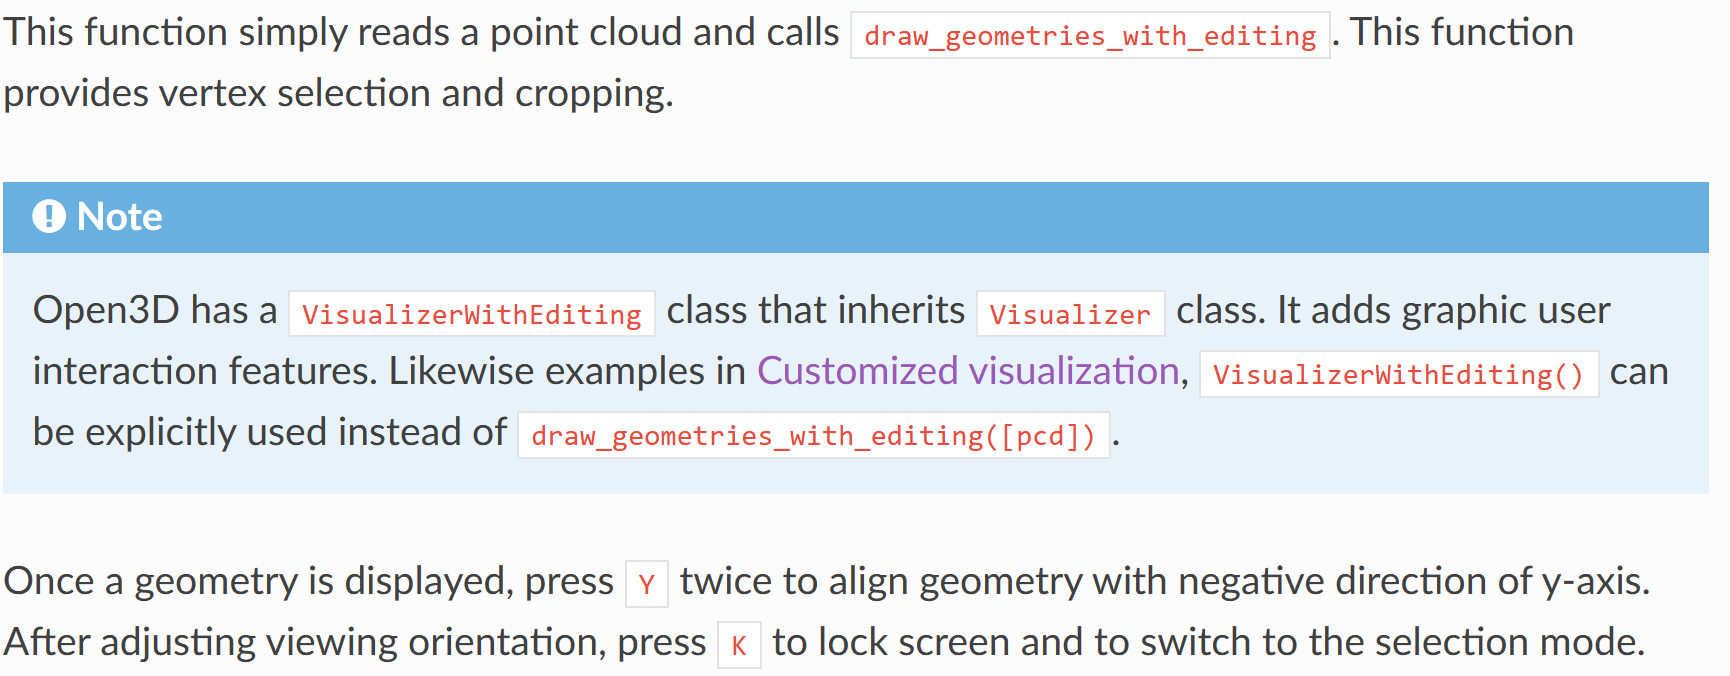

In [ ]:
#pcd = o3d.io.read_point_cloud(pcd_data.paths[0])
sample_data = o3d.data.DemoCustomVisualization()
pcd_flipped = o3d.io.read_point_cloud(sample_data.point_cloud_path)
pcd_flipped.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0],
                           [0, 0, 0, 1]])
o3d.visualization.draw_geometries_with_editing([pcd_flipped])

In [ ]:
# Manual global registration moved to final ICP cell for combined workflow.


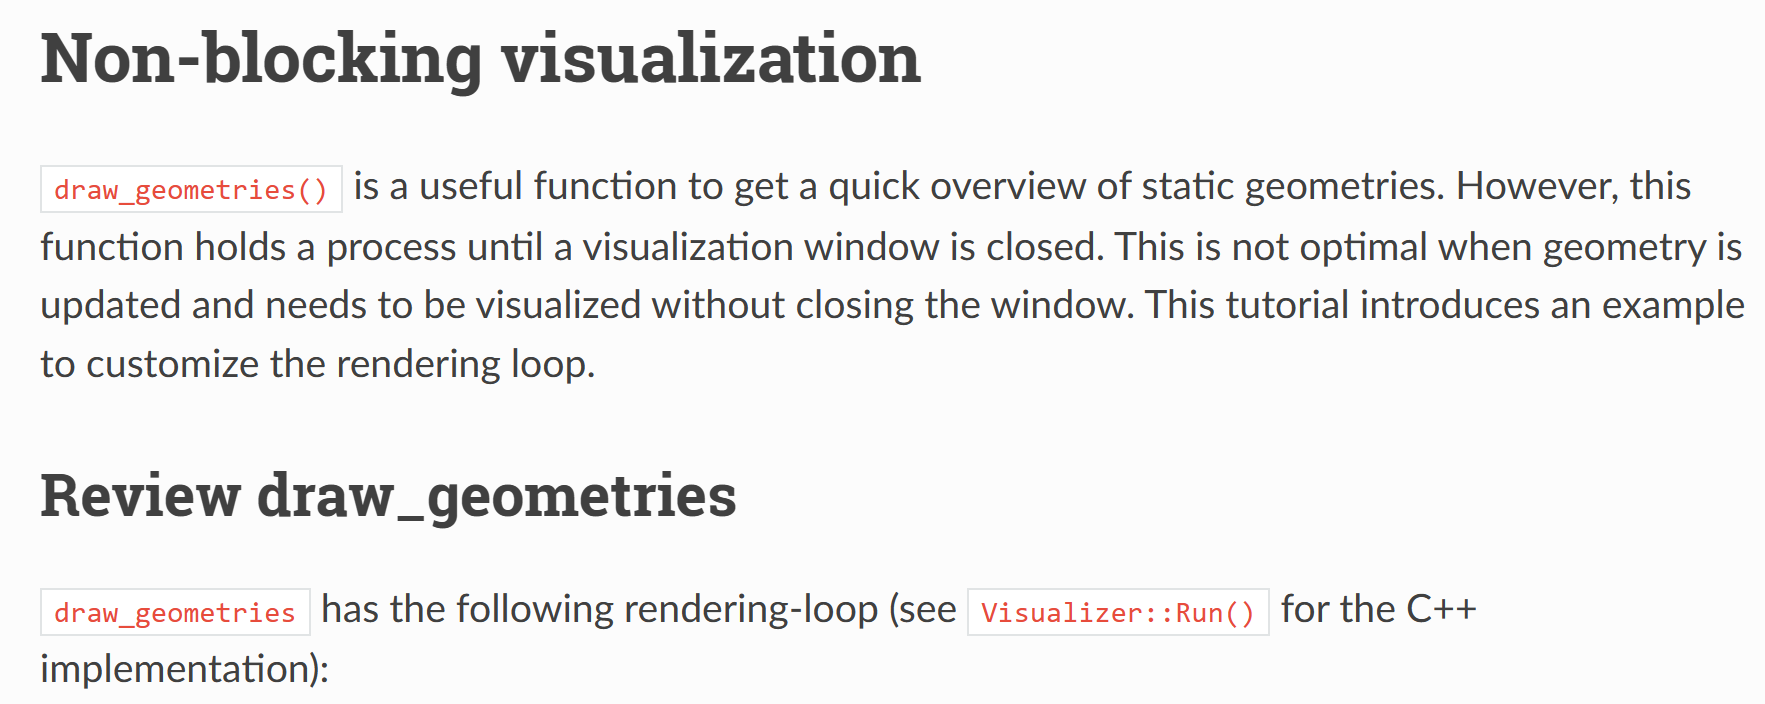

In [ ]:
while(true):
    if (geometry has changed):
        re-bind geometry to shaders
    if (view parameters have changed):
        re-render the scene
    if (any user mouse/keyboard input):
        respond to it and set flags for re-rendering

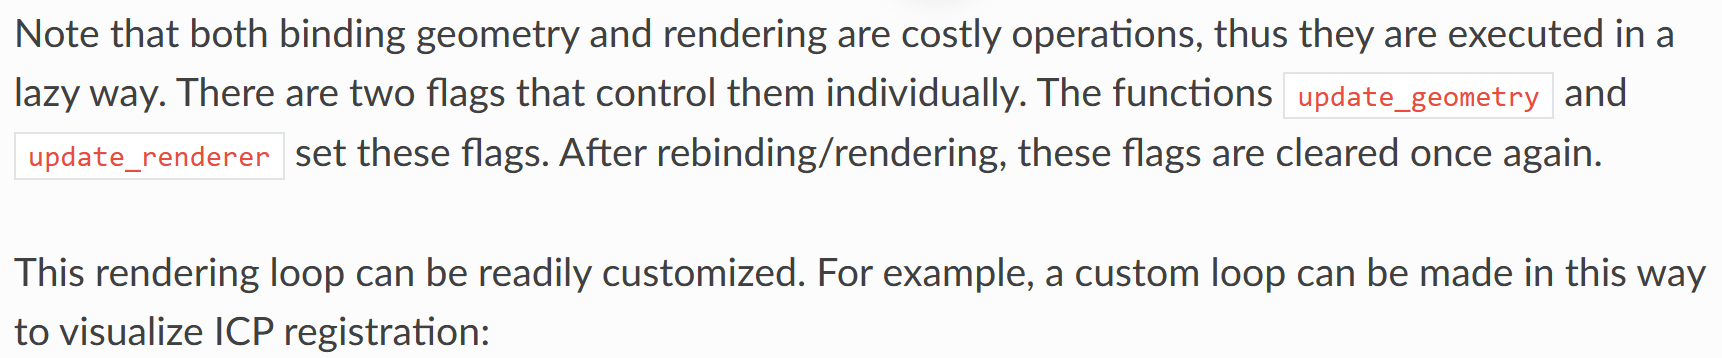

In [2]:
import open3d as o3d
import numpy as np
import copy

def draw_registration_result(source, target, transformation):
    source_temp = copy.deepcopy(source)
    target_temp = copy.deepcopy(target)
    source_temp.paint_uniform_color([1, 0.706, 0])
    target_temp.paint_uniform_color([0, 0.651, 0.929])
    source_temp.transform(transformation)
    o3d.visualization.draw_geometries([source_temp, target_temp])

def pick_points(pcd, label):
    print(f"Picking on {label} (Shift+左鍵選點，Shift+右鍵取消，按 Q 結束)")
    vis = o3d.visualization.VisualizerWithEditing()
    vis.create_window(window_name=f"Pick points: {label}")
    vis.add_geometry(pcd)
    vis.run()
    vis.destroy_window()
    return vis.get_picked_points()

def manual_global_registration():
    print("Manual global registration: pick correspondences from source, then target.")
    pcd_data = o3d.data.DemoICPPointClouds()
    source = o3d.io.read_point_cloud(pcd_data.paths[0])
    target = o3d.io.read_point_cloud(pcd_data.paths[2])

    print("Visualization of two point clouds before manual alignment")
    draw_registration_result(source, target, np.identity(4))

    picked_id_source = pick_points(source, label="source")
    picked_id_target = pick_points(target, label="target")
    assert (len(picked_id_source) >= 3 and len(picked_id_target) >= 3)
    assert (len(picked_id_source) == len(picked_id_target))
    corr = np.zeros((len(picked_id_source), 2))
    corr[:, 0] = picked_id_source
    corr[:, 1] = picked_id_target

    print("Compute a rough transform using the correspondences given by user")
    p2p = o3d.pipelines.registration.TransformationEstimationPointToPoint()
    trans_init = p2p.compute_transformation(
        source, target, o3d.utility.Vector2iVector(corr))

    print("Initial alignment using manually picked correspondences")
    draw_registration_result(source, target, trans_init)

    return source, target, trans_init

# Step 1: manual global registration to get an initial alignment
source, target, trans_init = manual_global_registration()

# Step 2: local ICP refinement starting from the manual alignment
threshold = 0.03
icp_iteration = 500
save_image = False

# Apply the manual alignment before starting ICP
source.transform(trans_init)

vis = o3d.visualization.Visualizer()
vis.create_window()
vis.add_geometry(source)
vis.add_geometry(target)

for i in range(icp_iteration):
    reg_p2l = o3d.pipelines.registration.registration_icp(
        source, target, threshold, np.identity(4),
        o3d.pipelines.registration.TransformationEstimationPointToPlane(),
        o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=1))
    source.transform(reg_p2l.transformation)
    vis.update_geometry(source)
    vis.poll_events()
    vis.update_renderer()
    if save_image:
        vis.capture_screen_image(f"temp_{i:04d}.jpg")

vis.destroy_window()
o3d.utility.set_verbosity_level(o3d.utility.VerbosityLevel.Info)


Manual global registration: pick correspondences from source, then target.
Visualization of two point clouds before manual alignment
Picking on source (Shift+左鍵選點，Shift+右鍵取消，按 Q 結束)
Picking on target (Shift+左鍵選點，Shift+右鍵取消，按 Q 結束)


AssertionError: 

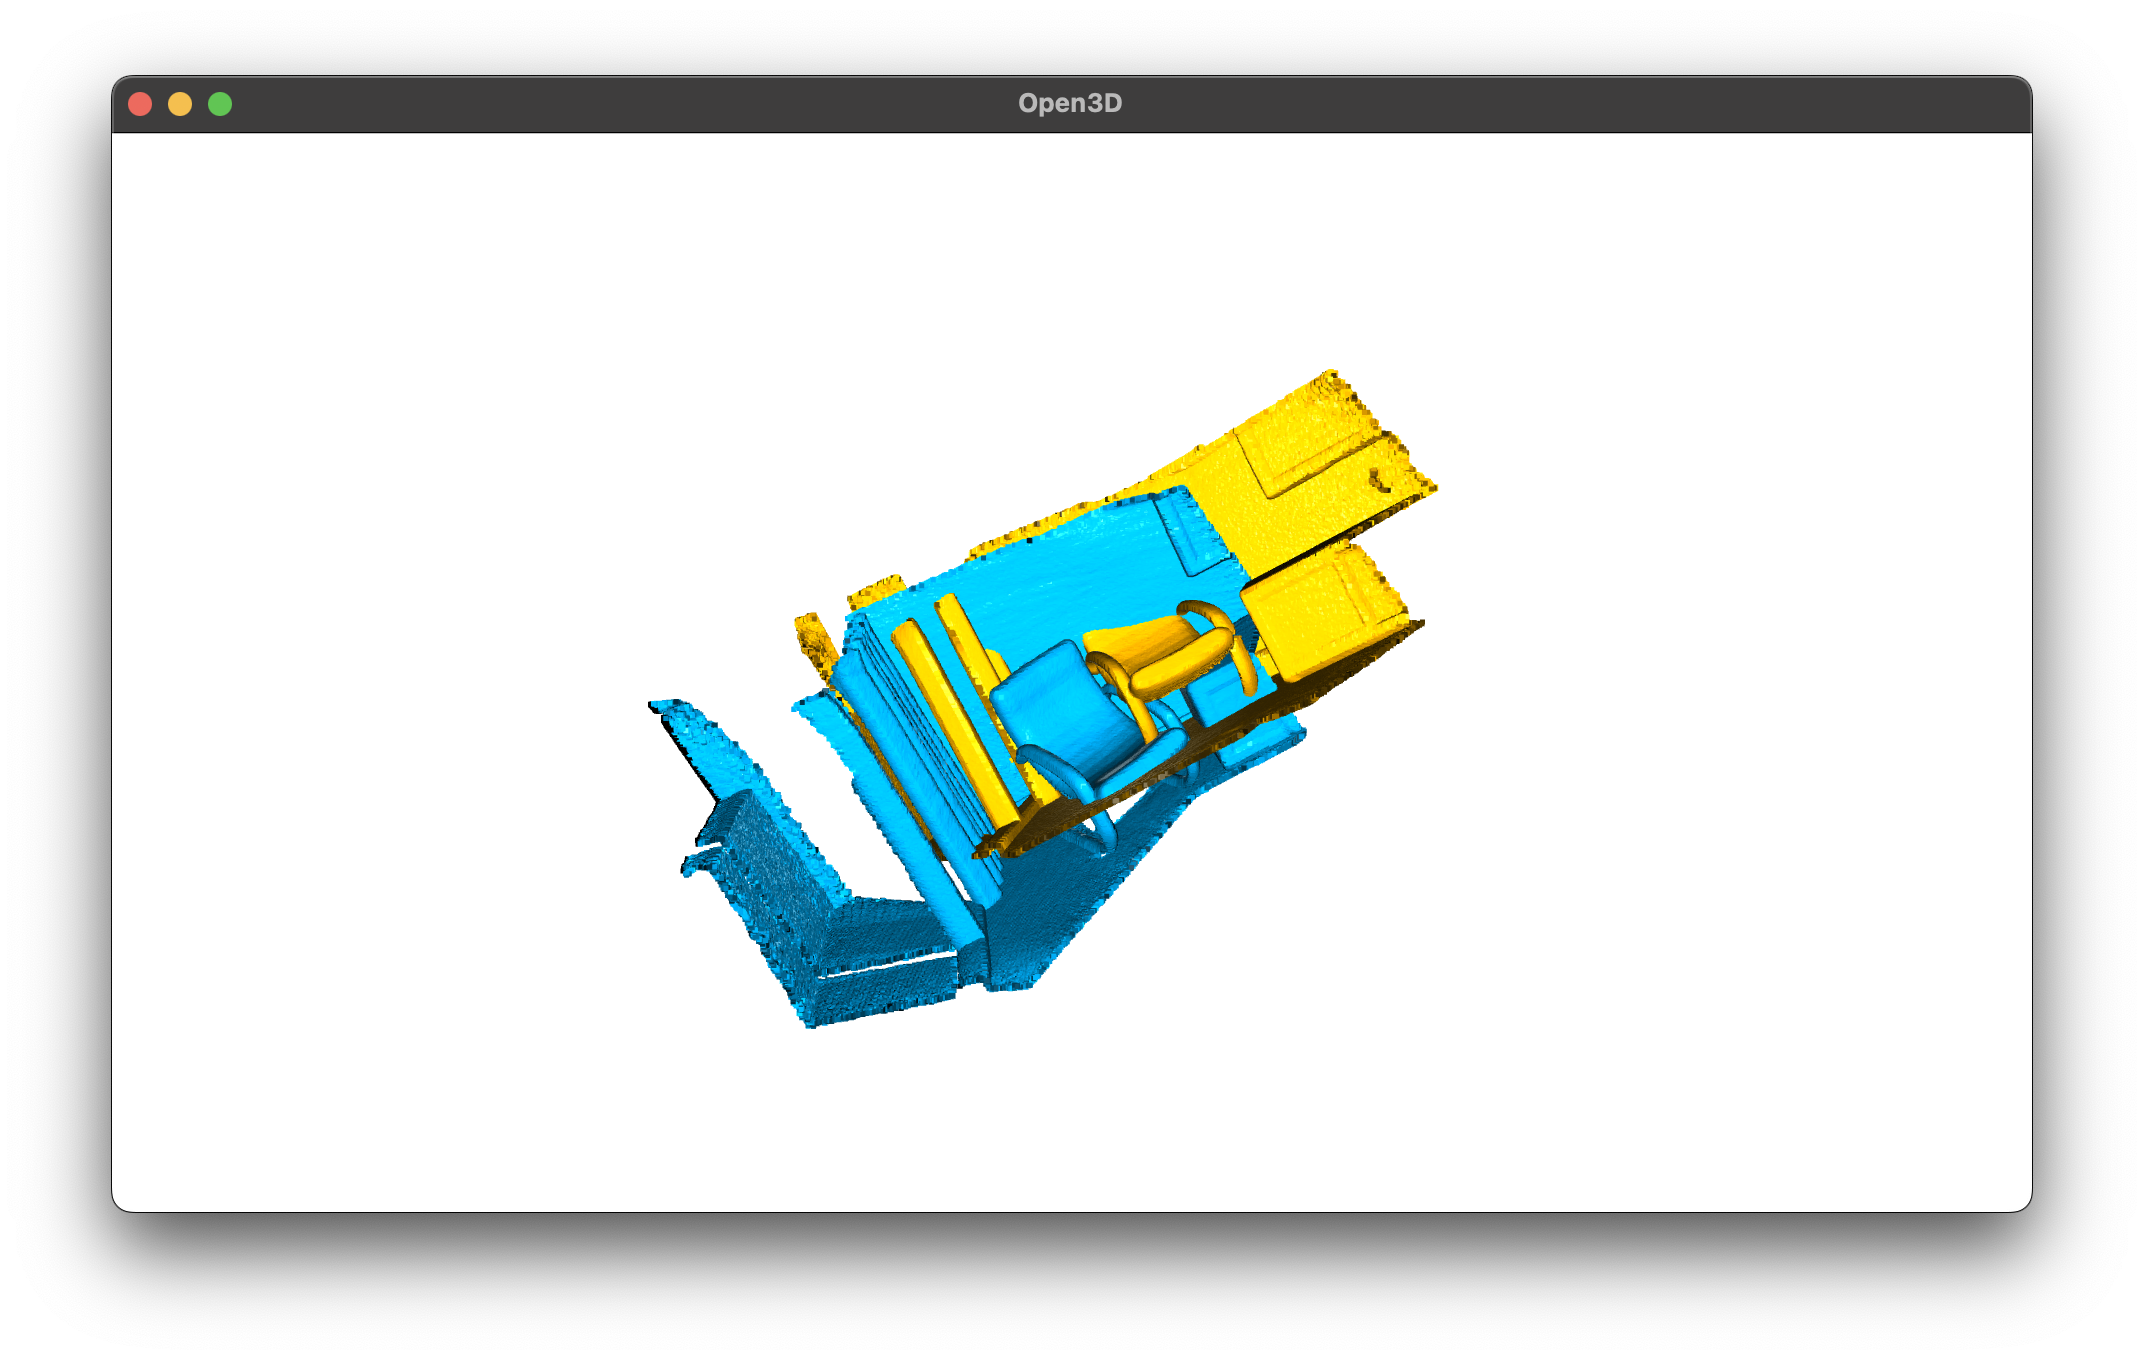